A simple ANN (Artificial Neural Network) can still recognize handwritten digits because it learns patterns in the pixel values of the images from the MNIST dataset.



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9332 - loss: 0.2344
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9700 - loss: 0.0993
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9785 - loss: 0.0679
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9826 - loss: 0.0544
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9861 - loss: 0.0429
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9774 - loss: 0.0754
Test Accuracy: 0.977400004863739
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


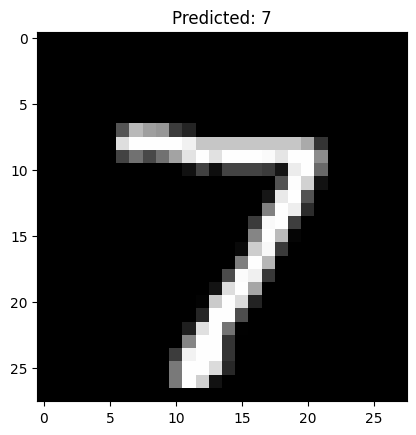

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize data (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Build Neural Network
model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
'''
Flatten Layer Converts Image → Vector
The network cannot directly process a 2D image, so we convert it into a 1D vector.

28 × 28 = 784
So the image becomes:
[0,0,0,0,0,255,255,0,255,255,0,...]

This 784-length vector becomes the input layer.


Dense Layer learns patterns
Each neuron computes:
output = activation( Σ(weight × input) + bias )
The network adjusts weights to detect patterns.
Patterns like:
high pixels in top row → maybe digit 7
loop pattern → maybe 8
vertical line → maybe 1

Activation Function Adds Non-Linearity to learn complex patterns


Output Layer Predicts Digit
It uses Softmax → converts outputs into probabilities
Example output:
[0.01, 0.02, 0.90, 0.01, 0.01, 0.02, 0.01, 0.01, 0.00, 0.01]
The highest probability is digit 2 (90%).
'''

# Compile model
model.compile(
    optimizer='adam', #advanced optimizer to update weights
    loss='sparse_categorical_crossentropy', #[0,0,0,1,0,0,0,0,0,0] ❌ but 3 ✔ is stored in labels, and output is [0.01,0.02,0.05,0.80,0.03,0.02,0.01,0.02,0.02,0.02] so use sparse(bht sare 0) categorical cross entropy
    metrics=['accuracy'] #multiclass classification
)

# Train model
model.fit(x_train, y_train, epochs=5)

# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

# Predict a digit
prediction = model.predict(x_test)

# Show image

plt.imshow(x_test[0], cmap='gray') #image available in dataset
plt.title("Predicted: {}".format(prediction[0].argmax())) #predicted digit as title
plt.show()